# HW14: Эмбеддинги, FAISS, RAG-пайплайн

## 1. Импорты, seed и среда

In [1]:
import random
import numpy as np
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import faiss
import torch
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [2]:
# Фиксируем seed 
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
# Определяем устройство.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 2. База знаний и первичный анализ

In [4]:
# Загрузка базы знаний
with open("knowledge_base.json", "r", encoding="utf-8") as f:
    knowledge_base = json.load(f)

print(f"Загружено {knowledge_base['statistics']['total_documents']} документов")

# Доступ к документам
for doc in knowledge_base['documents']:
    print(f"{doc['id']}. {doc['title']} ({doc['category']})")


print('\nСреднее количество символов в документе: ')
print(int(np.average([len(knowledge_base["documents"][i]['content']) for i in range(len(knowledge_base["documents"]))])))

Загружено 20 документов
1. Что такое Docker? (Основы)
2. Docker образы и слои (Основы)
3. Dockerfile: инструкции (Сборка образов)
4. Управление контейнерами (Запуск и управление)
5. Docker Compose для многоконтейнерных приложений (Оркестрация)
6. Тома и постоянное хранение данных (Хранение данных)
7. Сети в Docker (Сети)
8. Docker для Data Science: лучшие практики (Data Science)
9. Docker Hub и реестры образов (Реестры)
10. Dockerfile для ML-проекта (пример) (Примеры)
11. docker-compose.yml для DS-проекта (пример) (Примеры)
12. Оптимизация размера образов (Оптимизация)
13. Логирование и мониторинг контейнеров (Мониторинг)
14. Безопасность в Docker (Безопасность)
15. Docker vs Виртуальные машины (Сравнение)
16. Docker Compose: переменные окружения (Оркестрация)
17. Кэширование слоёв при сборке (Оптимизация)
18. Healthcheck в Docker (Мониторинг)
19. Оркестрация контейнеров: Docker Swarm vs Kubernetes (Оркестрация)
20. Частые ошибки и их решение (Отладка)

Среднее количество символов в до

**Почему выбрана эта предметная область:**
- Docker — стандарт де-факто для MLOps и Data Science
- Чёткие концепции (образы, контейнеры, тома, сети)
- Часто задаваемые вопросы в реальной работе
- Фактологичные ответы (команды, параметры)
- Идеально для демонстрации RAG-пайплайна

## 3. Чанкинг документов

In [5]:
# Параметры чанкинга
CHUNK_SIZE = 200 
OVERLAP = 100 
top_k = 3

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]
)

# Применяем чанкинг ко всем документам
chunks = []
for doc in knowledge_base['documents']:
    doc_chunks = splitter.split_text(doc['content'])
    for chunk_id, chunk in enumerate(doc_chunks):
        chunks.append({
            'doc_id': doc['id'],
            'title': doc['title'],
            'chunk_id': chunk_id,
            'chunk_text': chunk,
            'chunk_len': len(chunk)
        })

chunks_df = pd.DataFrame(chunks)
print(f"Создано {len(chunks_df)} чанков из {len(knowledge_base['documents'])} документов")
print(f"Размер чанка: {CHUNK_SIZE} символов, overlap: {OVERLAP} символов")

# Показываем пример чанкинга для документа №12
print("\nПример: чанкинг документа 'Оптимизация размера образов' (док.12)")
doc12_chunks = chunks_df[chunks_df['doc_id'] == 12]
for i, (_, row) in enumerate(doc12_chunks.head(3).iterrows()):
    print(f"\n--- Чанк {i+1} (ID {row['chunk_id']}) ---")
    print(f"Текст: {row['chunk_text'][:CHUNK_SIZE//2]}...")
    print(f"Длина: {row['chunk_len']} символов")

Создано 82 чанков из 20 документов
Размер чанка: 200 символов, overlap: 100 символов

Пример: чанкинг документа 'Оптимизация размера образов' (док.12)

--- Чанк 1 (ID 0) ---
Текст: Методы уменьшения размера Docker образов: 1) Используйте многоступенчатую сборку (multi-stage build)...
Длина: 182 символов

--- Чанк 2 (ID 1) ---
Текст: . 2) Объединяйте команды RUN в одну (RUN apt-get update && apt-get install -y ...). 3) Очищайте кэш ...
Длина: 175 символов

--- Чанк 3 (ID 2) ---
Текст: . 3) Очищайте кэш пакетов: rm -rf /var/lib/apt/lists/*. 4) Используйте --no-cache-dir для pip. 5) Вы...
Длина: 129 символов


**Почему выбраны параметры:**
- `chunk_size=200` символов (примерно треть/половина документа) — охватывает цельную мысль
- `chunk_overlap=100` символов — сохраняет контекст на границах
- Размер обеспечивает ~2-4 предложения на чанк — достаточно для ответа на простой вопрос

## 4. Эмбеддинги и индекс FAISS

In [6]:
# Загружаем embedding-модель
model = SentenceTransformer('intfloat/multilingual-e5-small', device=device)
EMBEDDING_DIM = model.get_embedding_dimension()
print(f"Модель загружена: intfloat/multilingual-e5-small")
print(f"Размерность эмбеддингов: {EMBEDDING_DIM}")

# Форматирование для модели E5
def prepare_passage(text: str) -> str:
    return f"passage: {text}"

def prepare_query(query: str) -> str:
    return f"query: {query}"

# Строим эмбеддинги для чанков
prepared_texts = [prepare_passage(text) for text in chunks_df['chunk_text'].tolist()]
embeddings = model.encode(prepared_texts, normalize_embeddings=True, show_progress_bar=True)
print(f"Построены эмбеддинги: {embeddings.shape}")

# Создаём FAISS индекс
index = faiss.IndexFlatIP(EMBEDDING_DIM)
index.add(embeddings.astype(np.float32))
print(f"FAISS индекс создан: {index.ntotal} векторов")

# Сохраняем метаданные
faiss_metadata = {
    'doc_id': chunks_df['doc_id'].tolist(),
    'title': chunks_df['title'].tolist(),
    'chunk_text': chunks_df['chunk_text'].tolist(),
    'chunk_id': chunks_df['chunk_id'].tolist()
}

# Функция поиска
def search(query: str, k: int = top_k):
    prepared_q = prepare_query(query)
    q_emb = model.encode([prepared_q], normalize_embeddings=True).astype(np.float32)
    scores, indices = index.search(q_emb, k)
    
    results = []
    for i, (idx, score) in enumerate(zip(indices[0], scores[0])):
        results.append({
            'rank': i + 1,
            'similarity_score': float(score),
            'doc_id': faiss_metadata['doc_id'][idx],
            'title': faiss_metadata['title'][idx],
            'chunk_text': faiss_metadata['chunk_text'][idx]
        })
    return scores[0], indices[0], pd.DataFrame(results)

# Тестовые запросы
test_queries_search = [
    "Как уменьшить размер Docker образа?",
    "Что такое Docker Compose?",
    "Как войти в контейнер?",
    "Чем Docker отличается от виртуальной машины?",
    "Как настроить Jupyter в Docker?"
]

print("\nПримеры поиска (top-3):")
for q in test_queries_search[:2]:
    _, _, results = search(q, k=top_k)
    print(f"\nЗапрос: {q}")
    for _, row in results.iterrows():
        print(f"   {row['rank']}. [Док.{row['doc_id']}] {row['title']} (score={row['similarity_score']:.3f})")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена: intfloat/multilingual-e5-small
Размерность эмбеддингов: 384


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Построены эмбеддинги: (82, 384)
FAISS индекс создан: 82 векторов

Примеры поиска (top-3):

Запрос: Как уменьшить размер Docker образа?
   1. [Док.12] Оптимизация размера образов (score=0.941)
   2. [Док.2] Docker образы и слои (score=0.890)
   3. [Док.2] Docker образы и слои (score=0.884)

Запрос: Что такое Docker Compose?
   1. [Док.5] Docker Compose для многоконтейнерных приложений (score=0.931)
   2. [Док.11] docker-compose.yml для DS-проекта (пример) (score=0.874)
   3. [Док.5] Docker Compose для многоконтейнерных приложений (score=0.869)


## 5. Контрольные запросы и оценка retrieval

In [7]:
# Контрольные запросы с разметкой
test_queries = [
    {"query": "Как уменьшить размер Docker образа?", "relevant_doc_ids": [12]},
    {"query": "Что делать, если порт занят?", "relevant_doc_ids": [20]},
    {"query": "Как настроить Jupyter в Docker?", "relevant_doc_ids": [8, 5]},
    {"query": "Чем Docker отличается от виртуальных машин?", "relevant_doc_ids": [15]},
    {"query": "Как сохранить данные после удаления контейнера?", "relevant_doc_ids": [6]},
    {"query": "Что такое Docker Compose?", "relevant_doc_ids": [5]},
    {"query": "Как войти внутрь работающего контейнера?", "relevant_doc_ids": [4]},
    {"query": "Как сканировать образ на уязвимости?", "relevant_doc_ids": [14]}
]

# Расчёт метрик
def evaluate_retrieval(queries, k=top_k):
    results = []
    for q in queries:
        _, _, search_results = search(q['query'], k=k)
        retrieved = search_results['doc_id'].tolist()
        expected = q['relevant_doc_ids']
        
        # hit@k
        hit = 1 if any(doc in retrieved for doc in expected) else 0
        
        # recall@k
        recall = len(set(retrieved) & set(expected)) / len(expected)
        
        # rank первого релевантного
        rank = None
        for i, doc in enumerate(retrieved, 1):
            if doc in expected:
                rank = i
                break
        
        results.append({
            'query': q['query'],
            'expected_source': str(expected),
            'retrieved_sources': str(retrieved),
            'hit_at_k': hit,
            'recall_at_k': recall,
            'rank_of_first_relevant': rank if rank else -1
        })
    return pd.DataFrame(results)

eval_df = evaluate_retrieval(test_queries, k=top_k)
display(eval_df[['query', 'expected_source', 'retrieved_sources', 'hit_at_k', 'recall_at_k', 'rank_of_first_relevant']])

# Сводная статистика
print(f"hit@3: {eval_df['hit_at_k'].mean():.2%}")
print(f"recall@3: {eval_df['recall_at_k'].mean():.2%}")
print(f"Успешных запросов: {eval_df['hit_at_k'].sum()}/{len(eval_df)}")

# Анализ ошибок
failed = eval_df[eval_df['hit_at_k'] == 0]
if len(failed) > 0:
    print(f"\nЗапросы, где retrieval ошибся:")
    for _, row in failed.iterrows():
        print(f"   - {row['query']}")
        print(f"     Ожидал: {row['expected_source']}, Получил: {row['retrieved_sources']}")

,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,Как уменьшить размер Docker образа?,[12],"[12, 2, 2]",1,1.0,1
1,"Что делать, если порт занят?",[20],"[7, 20, 20]",1,1.0,2
2,Как настроить Jupyter в Docker?,"[8, 5]","[8, 11, 8]",1,0.5,1
3,Чем Docker отличается от виртуальных машин?,[15],"[1, 15, 15]",1,1.0,2
4,Как сохранить данные после удаления контейнера?,[6],"[6, 18, 4]",1,1.0,1
5,Что такое Docker Compose?,[5],"[5, 11, 5]",1,1.0,1
6,Как войти внутрь работающего контейнера?,[4],"[20, 20, 4]",1,1.0,3
7,Как сканировать образ на уязвимости?,[14],"[14, 12, 14]",1,1.0,1


hit@3: 100.00%
recall@3: 93.75%
Успешных запросов: 8/8


## 6. Эксперимент с параметрами retrieval

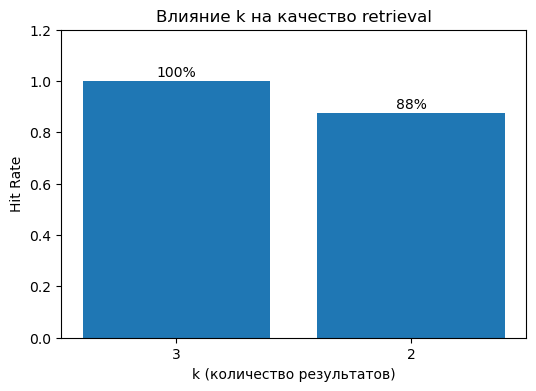

In [8]:
# Сравнение k=3 и k=5
k_values = [3, 2]
comparison = []

for k in k_values:
    hits = 0
    for q in test_queries:
        _, _, results = search(q['query'], k=k)
        retrieved = results['doc_id'].tolist()
        if any(doc in retrieved for doc in q['relevant_doc_ids']):
            hits += 1
    comparison.append({'k': k, 'hit_rate': hits/len(test_queries)})

comp_df = pd.DataFrame(comparison)

# Визуализация
plt.figure(figsize=(6, 4))
plt.bar(comp_df['k'].astype(str), comp_df['hit_rate'])
plt.xlabel('k (количество результатов)')
plt.ylabel('Hit Rate')
plt.title('Влияние k на качество retrieval')
plt.ylim(0, 1.2)
for i, row in comp_df.iterrows():
    plt.text(i, row['hit_rate'] + 0.02, f"{row['hit_rate']:.0%}", ha='center')
plt.show()

Качество retrieval уменьшается пропорционально уменьшению параметра k < 3 

## 7. Обновление базы знаний и переиндексация

In [9]:
new_docs = [
    {
        "id": 21,
        "title": "Docker Scout: сканирование уязвимостей",
        "category": "Безопасность",
        "difficulty": "intermediate",
        "tags": ["scout", "уязвимости", "безопасность", "scan"],
        "content": """Docker Scout — это инструмент для сканирования образов на уязвимости. 
        Команда: docker scout scan image:tag. Scout анализирует слои образа и сравнивает с CVE базами. 
        Выявляет критичные уязвимости и предлагает пути исправления. Интегрируется с CI/CD. 
        Пример: docker scout scan --format table python:3.9-slim. 
        Для локального сканирования: docker scout quickview image:tag. 
        Scout также показывает пути обновления пакетов для устранения уязвимостей."""
    },
    {
        "id": 22,
        "title": "Docker BuildKit: ускоренная сборка",
        "category": "Оптимизация",
        "difficulty": "advanced",
        "tags": ["buildkit", "сборка", "кэширование"],
        "content": """BuildKit — новый бэкенд сборки Docker (с 18.09). 
        Включение: export DOCKER_BUILDKIT=1 или в /etc/docker/daemon.json. 
        Преимущества: параллельная сборка этапов, улучшенное кэширование (--mount=type=cache), 
        сборка только изменённых этапов (--build-arg BUILDKIT_PROGRESS=plain), 
        секреты без оставления следов в образах (--secret id=mysecret,src=./secret.txt). 
        Пример: RUN --mount=type=cache,target=/root/.cache/pip pip install -r requirements.txt. 
        BuildKit ускоряет сборку в 2-5 раз для больших проектов."""
    },
    {
        "id": 23,
        "title": "Docker Debug: отладка контейнеров",
        "category": "Отладка",
        "difficulty": "intermediate",
        "tags": ["debug", "отладка", "диагностика"],
        "content": """Docker Debug (Docker Desktop 4.30+) — инструмент для отладки контейнеров. 
        Команда: docker debug container_name. Открывает интерактивную сессию внутри контейнера. 
       Позволяет: проверить процессы (ps aux), сетевые подключения (netstat), файловую систему (ls -la), 
        переменные окружения (env), логи (tail -f /var/log/app.log). 
        Пример: docker debug --pid=container_name — подключиться к пространству имён процессов. 
        Отладка без установки дополнительных инструментов в контейнер."""
    }
]

In [10]:
# Сохраняем старый индекс для сравнения
old_index = index
old_chunks_df = chunks_df.copy()
old_metadata = faiss_metadata.copy()

# Добавляем новые документы в базу
for d in new_docs:
    knowledge_base['documents'].append({
        'id': d['id'],
        'title': d['title'],
        'category': d['category'],
        'content': d['content']
    })

# Пересоздаём чанки
new_chunks = []
for doc in knowledge_base['documents']:
    doc_chunks = splitter.split_text(doc['content'])
    for chunk_id, chunk in enumerate(doc_chunks):
        new_chunks.append({
            'doc_id': doc['id'],
            'title': doc['title'],
            'chunk_id': chunk_id,
            'chunk_text': chunk
        })

new_chunks_df = pd.DataFrame(new_chunks)
print(f"После обновления: {len(new_chunks_df)} чанков (было: {len(chunks_df)})")

# Перестраиваем эмбеддинги и индекс
new_prepared = [prepare_passage(text) for text in new_chunks_df['chunk_text'].tolist()]
new_embeddings = model.encode(new_prepared, normalize_embeddings=True, show_progress_bar=True)
new_index = faiss.IndexFlatIP(EMBEDDING_DIM)
new_index.add(new_embeddings.astype(np.float32))

new_faiss_metadata = {
    'doc_id': new_chunks_df['doc_id'].tolist(),
    'title': new_chunks_df['title'].tolist(),
    'chunk_text': new_chunks_df['chunk_text'].tolist()
}

def search_new(query: str, k: int = 5):
    prepared_q = prepare_query(query)
    q_emb = model.encode([prepared_q], normalize_embeddings=True).astype(np.float32)
    scores, indices = new_index.search(q_emb, k)
    results = []
    for _, (idx, score) in enumerate(zip(indices[0], scores[0])):
        results.append({
            'doc_id': new_faiss_metadata['doc_id'][idx],
            'title': new_faiss_metadata['title'][idx],
            'similarity_score': float(score)
        })
    return pd.DataFrame(results)

# Сравнение до и после
comparison_queries = [
    "Как сканировать Docker образ на уязвимости?",
    "Как ускорить сборку Docker?",
    "Как уменьшить размер Docker образа?",
    "Что делать, если порт занят?"
]

comparison_results = []
for q in comparison_queries:
    # Старый поиск
    _, _, old_res = search(q, k=top_k)
    old_sources = old_res['doc_id'].tolist()
    
    # Новый поиск
    new_res = search_new(q, k=top_k)
    new_sources = new_res['doc_id'].tolist()
    
    comparison_results.append({
        'query': q,
        'before_retrieved_sources': str(old_sources),
        'after_retrieved_sources': str(new_sources),
        'changed': old_sources != new_sources
    })

before_after_df = pd.DataFrame(comparison_results)
print("\nСравнение retrival до и после обновления")
display(before_after_df)

# Обновляем глобальные переменные
index = new_index
chunks_df = new_chunks_df
faiss_metadata = new_faiss_metadata

После обновления: 96 чанков (было: 82)


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Сравнение retrival до и после обновления


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как сканировать Docker образ на уязвимости?,"[14, 14, 14]","[21, 21, 21]",True
1,Как ускорить сборку Docker?,"[12, 11, 20]","[12, 11, 20]",False
2,Как уменьшить размер Docker образа?,"[12, 2, 2]","[12, 2, 2]",False
3,"Что делать, если порт занят?","[7, 20, 20]","[7, 20, 20]",False


Модель смогла адаптироваться под запрос по новому документу

## 8. Mini-RAG

In [11]:
def split_into_sentences(text: str) -> list:
    sentences = re.split(r'[.!?]+', text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

def extract_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Разбиваем контекст на предложения
    lines = [line.strip() for line in context.split('\n') if line.strip()]
    content_lines = [line for line in lines if not line.startswith('[Источник:')]
    
    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))
    
    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]
    
    if not sentence_pool:
        return "Недостаточно контекста для ответа."
    
    # TF-IDF и косинусное сходство
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray()
    
    query_vec = matrix[0]
    sentence_vecs = matrix[1:]
    
    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)
    
    # Выбираем лучшие
    ranked_idx = np.argsort(-scores)
    selected = []
    seen = set()
    
    for idx in ranked_idx:
        sent = sentence_pool[idx]
        sent_norm = sent.lower().strip()
        if sent_norm in seen:
            continue
        seen.add(sent_norm)
        # Убираем номера списков
        sent = re.sub(r'^\d+\)\s*', '', sent)
        selected.append(sent)
        if len(selected) >= max_sentences:
            break
    
    return " ".join(selected) if selected else "Не найден релевантный фрагмент."

def mini_rag(query: str, k: int = top_k) -> dict:
    # 1. Retrieval
    _, _, results_df = search(query, k=k)
    
    if results_df.empty:
        return {"query": query, "answer": "Ничего не найдено.", "sources": []}
    
    # 2. Сбор контекста с источниками
    context_parts = []
    sources = []
    for _, row in results_df.iterrows():
        context_parts.append(f"[Источник: Док.{row['doc_id']} - {row['title']}]\n{row['chunk_text']}")
        sources.append({
            'doc_id': int(row['doc_id']),
            'title': row['title'],
            'similarity': row['similarity_score']
        })
    
    full_context = "\n\n".join(context_parts)
    
    # 3. Извлечение ответа
    answer = extract_answer_from_context(query, full_context, max_sentences=2)
    
    return {
        "query": query,
        "answer": answer,
        "sources": sources
    }

# Тестирование
rag_queries = [
    "Как уменьшить размер Docker образа?",
    "Что делать, если порт занят?",
    "Как настроить Jupyter в Docker?",
    "Чем Docker отличается от виртуальных машин?",
    "Как сканировать образ на уязвимости?"
]

rag_examples = []
for q in rag_queries:
    result = mini_rag(q, k=top_k)
    rag_examples.append(result)
    
    print(f"\nВопрос: {result['query']}")
    print(f"Ответ: {result['answer'][:200]}...")
    print(f"Источники: {', '.join([f'Док.{s["doc_id"]}' for s in result['sources']])}")
    print("-" * 50)

# Сохраняем для артефактов
rag_df = pd.DataFrame([{
    'question': r['query'],
    'answer': r['answer'],
    'retrieved_sources': ', '.join([f"Док.{s['doc_id']}:{s['title']}" for s in r['sources']])
} for r in rag_examples])
rag_df.to_csv('artifacts/rag_examples.csv', index=False, encoding='utf-8')


Вопрос: Как уменьшить размер Docker образа?
Ответ: Команды для работы: docker pull (скачать образ), docker images (список), docker rmi (удалить) Методы уменьшения размера Docker образов: 1) Используйте многоступенчатую сборку (multi-stage build)...
Источники: Док.12, Док.2, Док.2
--------------------------------------------------

Вопрос: Что делать, если порт занят?
Ответ: "Port already allocated": сменить порт или остановить конфликтующий контейнер Проброс портов: -p 8080:80 (хост:контейнер)...
Источники: Док.7, Док.20, Док.20
--------------------------------------------------

Вопрос: Как настроить Jupyter в Docker?
Ответ: Для Jupyter: EXPOSE 8888, CMD ["jupyter", "lab", "--ip=0 Команда запуска: docker-compose up -d...
Источники: Док.8, Док.11, Док.8
--------------------------------------------------

Вопрос: Чем Docker отличается от виртуальных машин?
Ответ: В отличие от виртуальных машин, контейнеры используют ядро хостовой ОС, что делает их легковесными Сравнение Docker контейне

Анализ ошибок:
1. Слишком общие вопросы - retrieval теряет фокус
2. Составные вопросы - RAG отвечает только на первую часть
3. Вопросы вне базы - retrieval находит ближайший семантический аналог

Основная проблема: нечеткие ответы - из-за TF-IDF экстракции без LLM-генерации

## 9. Сохранение артефактов

In [12]:
# 1. retrieval_eval.csv
eval_df.to_csv('artifacts/retrieval_eval.csv', index=False, encoding='utf-8')

# 2. rag_examples.csv (уже сохранён выше)

# 3. retrieval_before_after_update.csv
before_after_df.to_csv('artifacts/retrieval_before_after_update.csv', index=False, encoding='utf-8')

# Дополнительно: retrieval_metrics_summary.json
metrics_summary = {
    "total_queries": len(eval_df),
    "k": 3,
    "hit_at_k": float(eval_df['hit_at_k'].mean()),
    "recall_at_k": float(eval_df['recall_at_k'].mean()),
    "successful_queries": int(eval_df['hit_at_k'].sum()),
    "failed_queries": int(len(eval_df) - eval_df['hit_at_k'].sum())
}

with open('artifacts/retrieval_metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

print("Все артефакты сохранены:")
print("  - HW14/artifacts/retrieval_eval.csv")
print("  - HW14/artifacts/rag_examples.csv")
print("  - HW14/artifacts/retrieval_before_after_update.csv")
print("  - HW14/artifacts/retrieval_metrics_summary.json")

Все артефакты сохранены:
  - HW14/artifacts/retrieval_eval.csv
  - HW14/artifacts/rag_examples.csv
  - HW14/artifacts/retrieval_before_after_update.csv
  - HW14/artifacts/retrieval_metrics_summary.json
